## Document Loaders 
Are components in langchain, that are used to load data from various sources (Web, csv, PDF, etc) into a Standardize format, usually, as Document objects. Which then can be used for chunking, embedding, retrieval, generation. 

Document object looks like this: 
```python 
Document(
    page_content = "Acutal Text goes here",
    metadata = {'source': 'filename.pdf', ...}
)

Check out this documentation for more info -   
[Document Loaders](https://docs.langchain.com/oss/python/integrations/document_loaders)

Also note that - all these loaders that we will be using are made by community of langchain, and we can also build our own Loader (read documentation for more lol)

### 1. TextLoader
Loads text from .txt files   
Used for loading chat logs, code snippets, transcripts, scrapped text etc into Langchain pipeline   

Note that It creates a list of Document objects from given .txt file

In [3]:
from langchain_community.document_loaders import TextLoader

In [32]:
txt_loader = TextLoader(file_path="Docs/Cats.txt", encoding='utf-8')
doc = txt_loader.load()

print("Type of doc loaded:", type(doc))
print("Length: ", len(doc))
print("Content inside list:\n", doc)
print("__"*50)
print(type(doc[0]))
print(doc[0])

#To get page_content, metadata
print(doc[0].page_content)
print(doc[0].metadata)

Type of doc loaded: <class 'list'>
Length:  1
Content inside list:
 [Document(metadata={'source': 'Docs/Cats.txt'}, page_content='The cat (Felis catus), also called domestic cat and house cat, is a small carnivorous mammal. It is an obligate carnivore, requiring a predominantly meat-based diet. Its retractable claws are adapted to killing small prey species such as mice and rats. It has a strong, flexible body, quick reflexes, and sharp teeth, and its night vision and sense of smell are well developed. It is a social species, but a solitary hunter and a crepuscular predator. Cat communication includes meowing, purring, trilling, hissing, growling, grunting, and body language. It can hear sounds too faint or too high in frequency for human ears, such as those made by small mammals. It secretes and perceives pheromones. Cat intelligence is evident in its ability to adapt, learn through observation, and solve problems. Female domestic cats can have kittens from spring to late autumn in te

### 2. PyPDFLoading
Loads content from pdf, and converts each page into Document object. Hence, this gives a list of Document object for each page in a pdf.

Note - This uses PyPDF library under the hood, and is not so great with complex pdfs or scanned pdfs

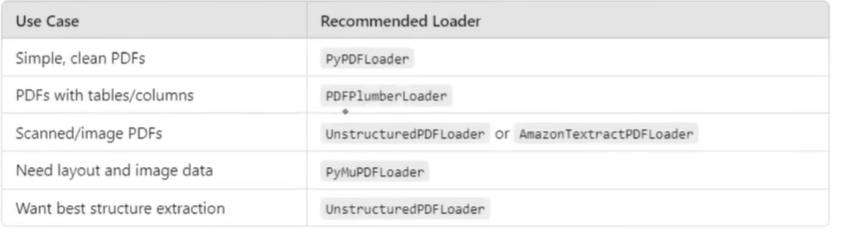

In [21]:
from langchain_community.document_loaders import PyPDFLoader

In [34]:
pdf_loader = PyPDFLoader(file_path="Docs/meri file.pdf", extract_images=False, mode='page')
doc = pdf_loader.load()

In [38]:
print(type(doc))
print(len(doc))
print(type(doc[0]))
print("__"*30)

for content in doc:
    print(content.page_content)
    print(content.metadata)
    print("\n")

<class 'list'>
8
<class 'langchain_core.documents.base.Document'>
____________________________________________________________
#include  <stdio.h>   int  main()  {      int  arr[50]  =  {1,  2,  3,  4};      int  n  =  4;      int  position,  element;      int  *ptr  =  arr;       printf("Position  for  insertion:  ");      scanf("%d",  &position);       printf("Element  for  insertion:  ");      scanf("%d",  &element);       //  Shift  elements  to  the  right      for  (int  i  =  n;  i  >=  position;  i--)  {          *(ptr  +  i)  =  *(ptr  +  i  -  1);      }       //  Insert  element      *(ptr  +  position  -  1)  =  element;      n++;       printf("Array  after  insertion:\n");      for  (int  i  =  0;  i  <  n;  i++)  {          printf("%d  ",  *(ptr  +  i));      }       return  0;  }
{'producer': 'Skia/PDF m148 Google Docs Renderer', 'creator': 'PyPDF', 'creationdate': '', 'title': 'meri file file.docx', 'source': 'Docs/meri file.pdf', 'total_pages': 8, 'page': 0, 'page_labe

### 3. Directory Loader
Helps you load multiple documents from a directory of files

In [39]:
from langchain_community.document_loaders import DirectoryLoader

In [44]:
dir_loader = DirectoryLoader(
    path = "Docs/Docs",
    glob = "*.pdf",        #Patterns/filter to take different files from directory
    loader_cls=PyPDFLoader
)

doc = dir_loader.load()

In [57]:
print(type(doc))
print(len(doc))
print(doc[0].page_content.replace("\n",""))
print(doc[0].metadata)

<class 'list'>
64
r    Guru Gobind Singh Indraprastha University Shahdara, Delhi     University School of Automation & Robotics (USAR)   IOT Manual  For  IIOT STUDENTS
{'producer': 'PDFium', 'creator': 'PDFium', 'creationdate': 'D:20230615105750', 'source': 'Docs\\Docs\\IOT Lab manual (1).pdf', 'total_pages': 28, 'page': 0, 'page_label': '1'}


### load vs lazy_load
Since the data can be huge and loaders may take long time to load the data all at once, we have the concept of lazy loading here

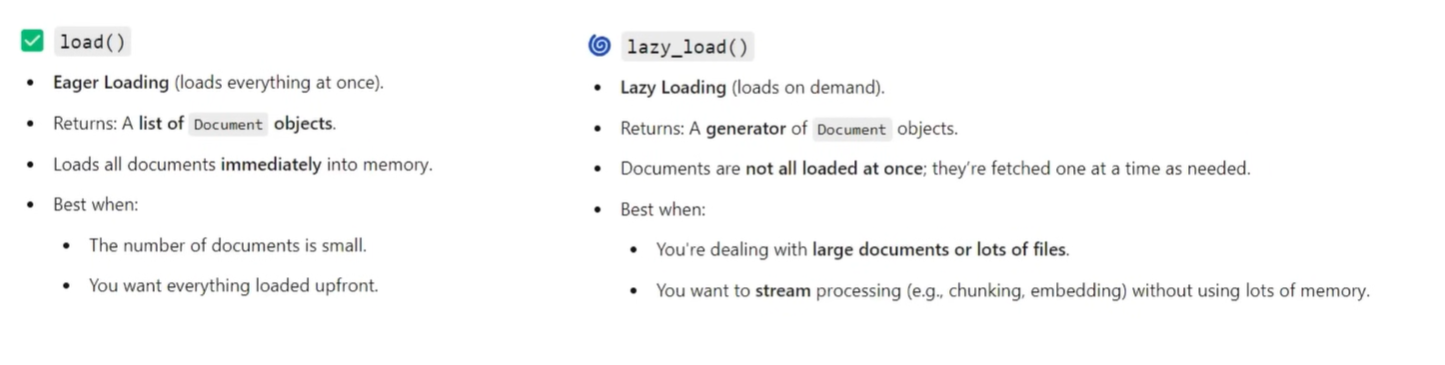

Run the cells below, and see the difference

In [65]:
# Will load everything first and then print
doc1 = dir_loader.load()
i = 0
for doc in doc1:
    i += 1
    print(i, end=", ")

1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 208, 209, 210, 211, 212, 213, 214, 215, 216, 217, 218, 219, 220, 221, 222

In [66]:
# Will load each Document one by one and print simultaneously
doc1 = dir_loader.lazy_load()
i = 0
for doc in doc1:
    i += 1
    print(i, end=", ")

1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 208, 209, 210, 211, 212, 213, 214, 215, 216, 217, 218, 219, 220, 221, 222

### WebBaseLoader
Uses Beautiful Soup to parse HTML and extract visible text, and Requests for HTTP requests, under the hood to load and extract text content from Web Pages (URLs). 

Works well with
- Primarily Text - based Static pages 
- For blogs, news articles 

In [87]:
from langchain_community.document_loaders import WebBaseLoader
import os

#We may have to set an env varaible "USER_AGENT" in some cases since, some websites do not allow requests that do not have valid "USER_AGENT"
os.environ["USER_AGENT"] = "MrGreedy"

url = "https://docs.langchain.com/oss/python/integrations/document_loaders"
web_loader = WebBaseLoader(web_path=url)

doc = web_loader.load()

In [89]:
print(type(doc))
print(len(doc))
print(doc)
print("__"*30)
print(doc[0].page_content) #This is not good at all lmao. Will have to explore other libraries

<class 'list'>
1
[Document(metadata={'source': 'https://docs.langchain.com/oss/python/integrations/document_loaders', 'title': 'Document loader integrations - Docs by LangChain', 'description': 'Integrate with document loaders using LangChain Python.', 'language': 'en'}, page_content='Document loader integrations - Docs by LangChainSkip to main contentJoin us May 13th & May 14th at Interrupt, the Agent Conference by LangChain. Buy tickets >Docs by LangChain home pageOpen sourceSearch...⌘KAsk AIGitHubTry LangSmithTry LangSmithSearch...NavigationIntegrations by componentDocument loader integrationsDeep AgentsLangChainLangGraphIntegrationsLearnReferenceContributePythonLangChain integrationsAll providersPopular ProvidersOpenAIAnthropicGoogleAWSNVIDIAHugging FaceMicrosoftOllamaGroqIntegrations by componentChat modelsTools and toolkitsMiddlewareSandboxesCheckpointersRetrieversText splittersEmbedding modelsVector storesDocument loadersOn this pageInterfaceBy categoryWebpagesPDFsCloud provider